In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Análise Exploratória — Dataset Olist E-commerce
## Portfólio de Análise de Dados | Python

**Objetivo:** Explorar o dataset público da Olist para identificar
padrões de vendas, comportamento de clientes e eficiência logística.

**Ferramentas:** Python · Pandas · Matplotlib · Seaborn

**Perguntas respondidas:**
1. Como os dados estão distribuídos?
2. Há sazonalidade nas vendas?
3. Quais produtos geram mais receita?
4. O prazo estimado de entrega está sendo cumprido?
5. Que fatores afetam a nota do cliente?

In [ ]:
# Importando Bibliotecas
# Pandas - para manipular tabelas de dados
# Matplotlib - para criar gráficos e formatar eixos (Ex: R$)
# Seaborn - visualização com visual mais bonito

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Carrega a tabela de pedidos — parse_dates converte as colunas de data
# para o formato datetime, permitindo cálculos com datas
orders    = pd.read_csv('olist_orders_dataset.csv', parse_dates=[
                'order_purchase_timestamp',
                'order_delivered_customer_date',
                'order_estimated_delivery_date'])
items     = pd.read_csv('olist_order_items_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
category  = pd.read_csv('product_category_name_translation.csv')

print('Dados carregados!')
print(f'Pedidos: {len(orders):,} linhas')
print(f'Itens:   {len(items):,} linhas')

Dados carregados!
Pedidos: 99,441 linhas
Itens:   112,650 linhas


In [ ]:
# Exibe o número de linhas e colunas de cada tabela
# Isso mostra o tamanho do dataset e ajuda a entender o volume de dados
print('=== SHAPE DOS DATASETS ===')
for nome, df in [('orders', orders), ('items', items),
                 ('payments', payments), ('reviews', reviews)]:
    print(f'{nome:12}: {df.shape[0]:>7,} linhas | {df.shape[1]} colunas')

print('\n=== VALORES NULOS EM ORDERS ===')
print(orders.isnull().sum()[orders.isnull().sum() > 0])

=== SHAPE DOS DATASETS ===
orders      :  99,441 linhas | 8 colunas
items       : 112,650 linhas | 7 colunas
payments    : 103,886 linhas | 5 colunas
reviews     :  99,224 linhas | 7 colunas

=== VALORES NULOS EM ORDERS ===
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


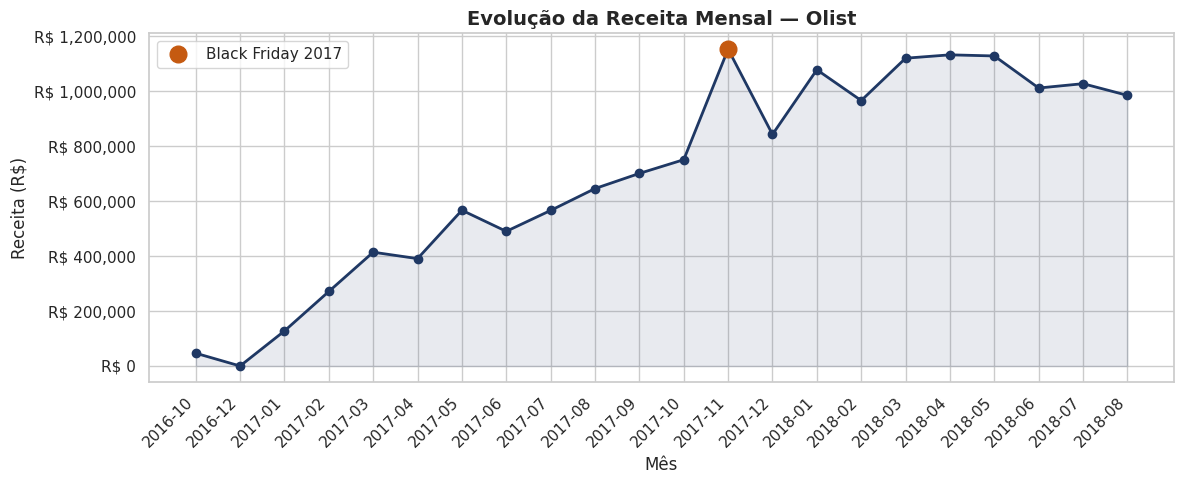


Mês de maior receita: 2017-11
Receita máxima: R$ 1,153,528.05


In [ ]:
# Filtra apenas pedidos com status 'delivered' (entregues)
# e faz um JOIN com a tabela de pagamentos pelo order_id
# Isso garante que só contamos receita de pedidos realmente concluídos
df = orders[orders['order_status'] == 'delivered'].merge(payments, on='order_id')

# agrupa por mês
receita = (df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))
             ['payment_value'].sum()
             .reset_index())
receita.columns = ['mes', 'receita']
receita['mes'] = receita['mes'].astype(str)

# gráfico
fig, ax = plt.subplots()
ax.plot(receita['mes'], receita['receita'], marker='o', color='#1F3864', linewidth=2)
ax.fill_between(range(len(receita)), receita['receita'], alpha=0.1, color='#1F3864')

# destaca novembro 2017
nov = receita[receita['mes'] == '2017-11'].index[0]
ax.plot(nov, receita.loc[nov, 'receita'], 'o', color='#C55A11', markersize=12,
        label='Black Friday 2017')

ax.set_title('Evolução da Receita Mensal — Olist', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.xticks(range(len(receita)), receita['mes'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('receita_mensal.png', dpi=150)
plt.show()

print(f"\nMês de maior receita: {receita.loc[receita['receita'].idxmax(), 'mes']}")
print(f"Receita máxima: R$ {receita['receita'].max():,.2f}")

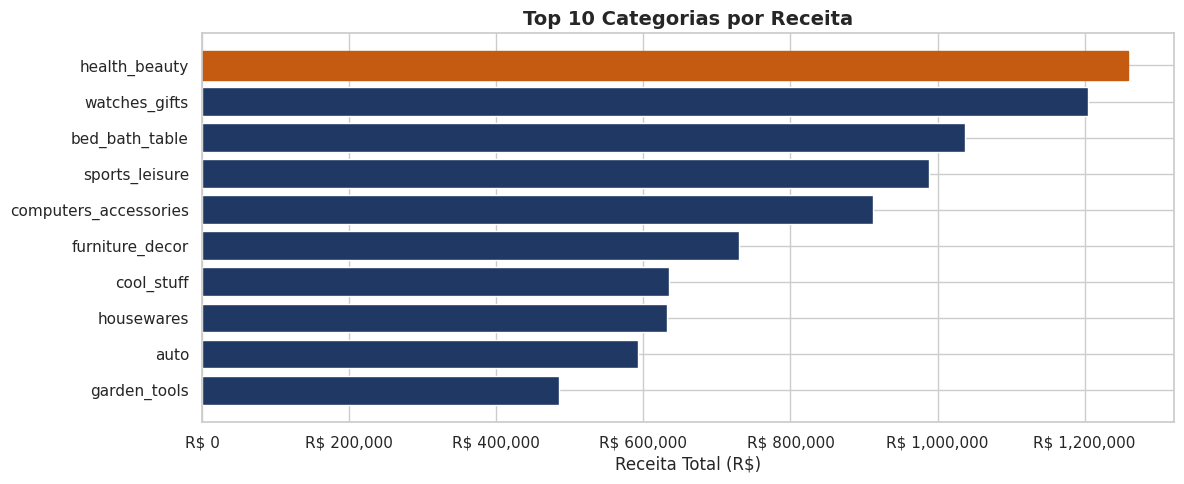

                                  receita  ticket_medio
product_category_name_english                          
health_beauty                  1258681.34        130.16
watches_gifts                  1205005.68        201.14
bed_bath_table                 1036988.68         93.30
sports_leisure                  988048.97        114.34
computers_accessories           911954.32        116.51
furniture_decor                 729762.49         87.56
cool_stuff                      635290.85        167.36
housewares                      632248.66         90.79
auto                            592720.11        139.96
garden_tools                    485256.46        111.63


In [ ]:
# junta itens + produtos + tradução
df_cat = (items.merge(products, on='product_id')
               .merge(category, on='product_category_name'))

# Agrupa por categoria e calcula três métricas:
# receita = soma total dos preços
# pedidos = contagem distinta de pedidos (evita contar duplicatas)
# ticket_medio = preço médio por item
top10 = (df_cat.groupby('product_category_name_english')
               .agg(receita=('price', 'sum'),
                    pedidos=('order_id', 'nunique'),
                    ticket_medio=('price', 'mean'))
               .sort_values('receita', ascending=False)
               .head(10))

# Cria gráfico de barras horizontais
fig, ax = plt.subplots()
bars = ax.barh(top10.index, top10['receita'], color='#1F3864')
bars[0].set_color('#C55A11')  # destaca o 1º

ax.set_title('Top 10 Categorias por Receita', fontsize=14, fontweight='bold')
ax.set_xlabel('Receita Total (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_categorias.png', dpi=150)
plt.show()

print(top10[['receita', 'ticket_medio']].round(2))

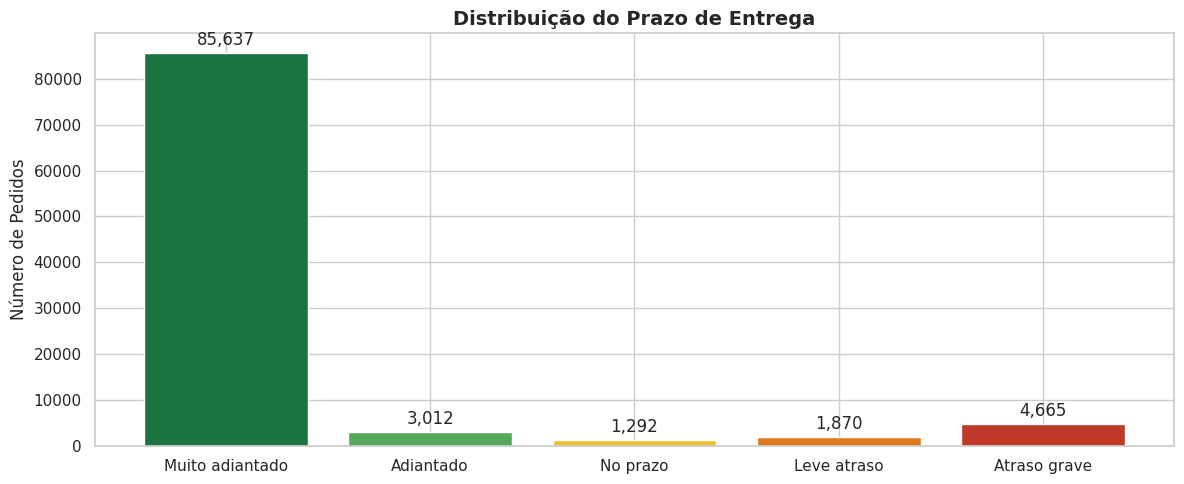


88.8% dos pedidos chegaram muito antes do prazo


In [ ]:
# Calcula o atraso em dias:
# positivo = chegou depois do prazo (atraso)
# negativo = chegou antes do prazo (adiantado)
df_entrega = orders[orders['order_delivered_customer_date'].notna()].copy()
df_entrega['dias_atraso'] = (
    df_entrega['order_delivered_customer_date'] -
    df_entrega['order_estimated_delivery_date']
).dt.days

# Função que classifica cada pedido em 5 categorias de prazo
def classifica(d):
    if d <= -3:   return 'Muito adiantado'
    elif d < 0:   return 'Adiantado'
    elif d == 0:  return 'No prazo'
    elif d <= 3:  return 'Leve atraso'
    else:         return 'Atraso grave'

df_entrega['situacao'] = df_entrega['dias_atraso'].apply(classifica)

# gráfico
ordem = ['Muito adiantado', 'Adiantado', 'No prazo', 'Leve atraso', 'Atraso grave']
cores = ['#1a7340', '#57a85a', '#f0c030', '#e07820', '#c0392b']
contagem = df_entrega['situacao'].value_counts().reindex(ordem)

fig, ax = plt.subplots()
bars = ax.bar(contagem.index, contagem.values, color=cores)
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Distribuição do Prazo de Entrega', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Pedidos')
plt.tight_layout()
plt.savefig('prazo_entrega.png', dpi=150)
plt.show()

pct_adiantado = (df_entrega['situacao'] == 'Muito adiantado').mean() * 100
print(f'\n{pct_adiantado:.1f}% dos pedidos chegaram muito antes do prazo')

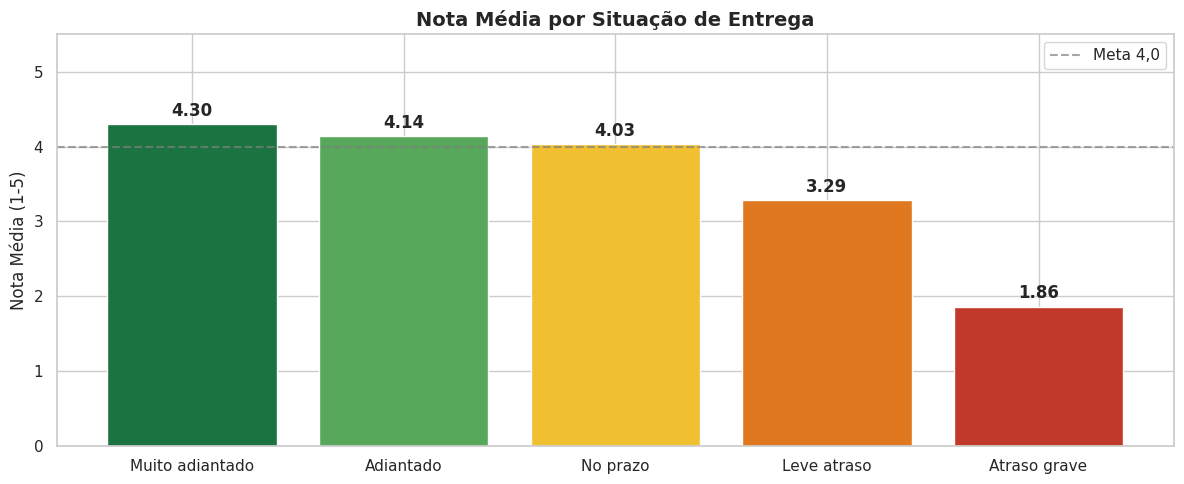

situacao
Muito adiantado    4.30
Adiantado          4.14
No prazo           4.03
Leve atraso        3.29
Atraso grave       1.86
Name: review_score, dtype: float64


In [ ]:
# junta com reviews
df_nota = df_entrega.merge(
    reviews[['order_id', 'review_score']], on='order_id')

nota_por_situacao = (df_nota.groupby('situacao')['review_score']
                            .mean()
                            .reindex(ordem)
                            .round(2))

# gráfico
fig, ax = plt.subplots()
bars = ax.bar(nota_por_situacao.index, nota_por_situacao.values, color=cores)
ax.bar_label(bars, fmt='{:.2f}', padding=3, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.axhline(y=4.0, color='gray', linestyle='--', alpha=0.7, label='Meta 4,0')
ax.set_title('Nota Média por Situação de Entrega', fontsize=14, fontweight='bold')
ax.set_ylabel('Nota Média (1-5)')
ax.legend()
plt.tight_layout()
plt.savefig('nota_por_atraso.png', dpi=150)
plt.show()

print(nota_por_situacao)

## Principais Conclusões

1. **Crescimento acelerado:** A receita cresceu ~10x entre out/2016 e nov/2017,
   com pico na Black Friday de R$ 1,15M.

2. **Concentração em poucas categorias:** As top 3 categorias respondem por
   35% da receita total. Health & Beauty lidera com R$ 1,26M.

3. **Estratégia de prazo conservadora:** 87% dos pedidos chegam muito antes
   do prazo estimado, sugerindo que a Olist usa prazos conservadores
   para gerenciar expectativas.

4. **Atraso é o principal driver de insatisfação:** Pedidos com atraso grave
   têm nota 1,85 vs 4,30 para pedidos adiantados — queda de 57%.
   Reduzir atrasos graves é a principal alavanca de melhoria de NPS.